In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import os 
os.chdir(r"C:\Users\DELL\Desktop\DEEP LEARNING PROJECT")
print(os.getcwd())

C:\Users\DELL\Desktop\DEEP LEARNING PROJECT


In [3]:
data=pd.read_csv("height-weight.csv")
data.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'Height vs Weight Plot')

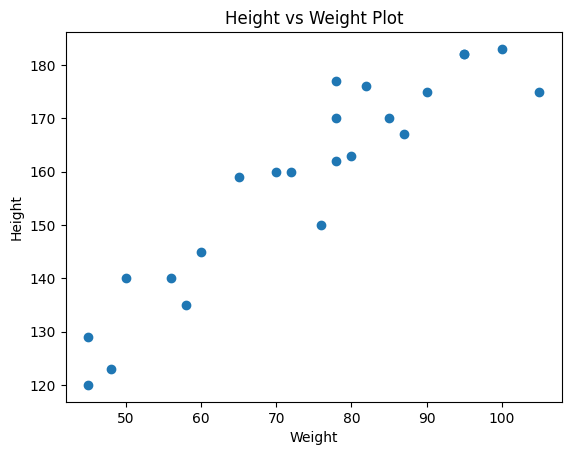

In [4]:
## scatter plot
plt.scatter(data['Weight'],data['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title("Height vs Weight Plot")

In [5]:
corr_mat=data.corr()
print(corr_mat)

          Weight    Height
Weight  1.000000  0.931142
Height  0.931142  1.000000


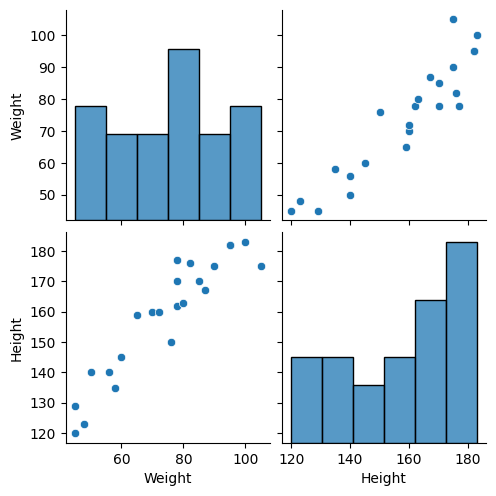

In [6]:
import seaborn as sns
sns.pairplot(data)

In [7]:
X=data[['Weight']]
print(type(X))
type(data)


<class 'pandas.core.frame.DataFrame'>


pandas.core.frame.DataFrame

In [8]:
X_series=data['Weight']
np.array(X_series).shape


(23,)

In [9]:
y=data['Height']
np.array(y).shape

(23,)

In [10]:
## Train Test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [11]:
X_train.shape
y_train.shape

(17,)

In [12]:
## Standardization Z score
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [13]:
X_train


array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [14]:
## Apply Linear Regression
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1)


In [15]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [16]:
regression

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [17]:
print("Cofficient of a Slope",regression.coef_)
print("Intercept",regression.intercept_)

Cofficient of a Slope [17.2982057]
Intercept 156.47058823529412


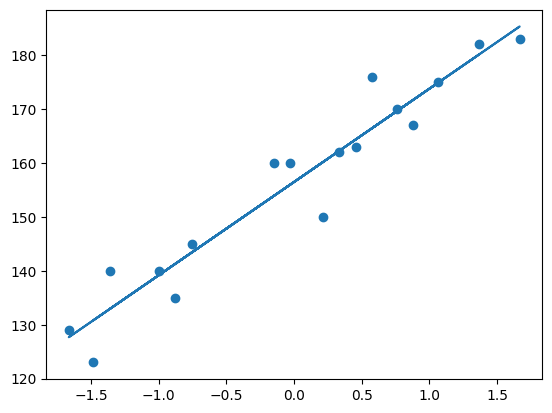

In [18]:
## plot best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

In [19]:
## prediction for test data
y_pred=regression.predict(X_test)

In [20]:
## performance matrix
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [21]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


In [22]:
## R square metric
from sklearn.metrics import r2_score


In [23]:
score=r2_score(y_test,y_pred)
print(score)

0.7360826717981276


In [24]:
## Adjusted R square metric
1-(1-score)*len((y_test)-1)/(len(y_test)-X_test.shape[1]-1)





0.6041240076971914

In [25]:
## OLS Linear Regression
!pip install statsmodels
import statsmodels.api as sm

In [26]:
model=sm.OLS(y_train,X_train).fit()


In [27]:
prediction=model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [28]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sun, 22 Mar 2026   Prob (F-statistic):                       0.664
Time:                        18:31:26   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\DELL\venv\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [31]:
## prediction for the new data
## we will get error in output because no scaling in test data
regression.predict([[72]])

array([1401.94139895])

In [32]:
## prediction for the new data
regression.predict(scaler.transform([[72]]))

c:\Users\DELL\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])